In [26]:
import pandas as pd
import fitz
import cv2
from io import BytesIO
from PIL import Image
import base64
from openai import OpenAI
from pydantic import BaseModel
import json
import numpy as np
import traceback
from typing import Optional

import pandas as pd
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.styles import Alignment, Border, Side, Font

from blank_functions.forms.form_recognition import FormRecognition
from blank_functions.ui.ui_functions import get_pic_from_pdf, save_to_excel, get_correct_answers, postprocess_raw_output, check_answers, final_styling, extract_text_from_image, transform_json_to_dataframe
from blank_functions.ui.ui_functions import promt, prepare_cur_dict

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# no limit columns for pandas
pd.set_option('display.max_columns', None)

In [27]:
# import time

# pdf_path = "C:/Users/zamko/Documents/mom_project/repo/data/valid_format/valid_questions.pdf"
# answers_path = "C:/Users/zamko/Documents/mom_project/repo/data/answers.xlsx"
# template_path = "C:/Users/zamko/Documents/mom_project/repo/data/template_2.jpg"
# json_path = "C:/Users/zamko/Documents/mom_project/repo/data/rows_data.json"

# pdf_bytes = open(pdf_path, 'rb').read()
# pdf_document = fitz.open(stream=pdf_bytes, filetype="pdf")
# num_pages = pdf_document.page_count

# answers_bytes = open(answers_path, 'rb').read()
# answers = pd.read_excel(BytesIO(answers_bytes))

# cur_version = 2

# df_global = pd.DataFrame()
# form_dict = {}
# for i in range(0, num_pages):
#     cur_pic = get_pic_from_pdf(pdf_bytes, i, zoom=6.0)
#     form = FormRecognition(
#         image = cur_pic,
#         template_path = template_path,
#         json_path = json_path,
#         answers = answers,
#         version = cur_version)
#     form = form.run_pipeline()
#     cur_dict = prepare_cur_dict(form)
#     df_current = transform_json_to_dataframe(cur_dict)
#     df_global = pd.concat([df_global, df_current]).reset_index(drop=True)
#     form_dict[i] = form

In [28]:
# cells_images = list()
# for key in form_dict.keys():
#     form = form_dict[key]
#     for row in ["user_id", "version"] + [f"answer{i}" for i in range(1, 11)] + [f"correction{i}" for i in range(1, 11)]:
#         for cell in getattr(form, row).cells:
#             if cell.user_value != None:
#                 # plt.figure(figsize=(1, 1))
#                 # plt.imshow(cell.cell_pred_input, cmap='gray')
#                 # plt.axis('off')
#                 # plt.show()
#                 cells_images.append(cell.cell_pred_input)




In [29]:
# import pickle

# with open('cells_images_total.pkl', 'wb') as f:
#     pickle.dump(cells_images, f)





In [41]:
import pickle
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Загрузка картинок
with open('cells_images_total.pkl', 'rb') as f:
    cells_images = pickle.load(f)

cells_images = cells_images[25:50]  # Ограничиваем до 30 картинок
cells_images = [255 - x for x in cells_images]
# добавь в каждый image жёлтую рамку
border_color = (0, 0, 0)  # Yellow color
border_width = 5  # Width of the border

def add_border(image, border_color, border_width):
    if len(image.shape) == 2:
        height, width = image.shape
    else:
        height, width, _ = image.shape
    new_image = np.zeros((height + 2 * border_width, width + 2 * border_width, 3), dtype=np.uint8)
    new_image[:, :] = border_color
    new_image[border_width:-border_width, border_width:-border_width, :] = np.stack([image]*3, axis=-1) if len(image.shape) == 2 else image
    return new_image

def check_and_label_empty(image):
    if len(image.shape) == 2:
        height, width = image.shape
        total_pixels = height * width
        if np.sum(image) == 255 * total_pixels:
            image = 255 - image
    else:
        height, width, _ = image.shape
        total_pixels = height * width * 3
        if np.sum(image) == 255 * total_pixels:
            image = 255 - image
           
    return image

cells_images = [check_and_label_empty(image) for image in cells_images]
cells_images = [add_border(image, border_color, border_width) for image in cells_images]

# Параметры сетки
num_cells = len(cells_images)
cells_per_column = 5  # Количество изображений в одном столбце
num_columns = (num_cells + cells_per_column - 1) // cells_per_column  # Число столбцов

# Создание фигуры для отображения (уменьшенные размеры)
fig, axs = plt.subplots(cells_per_column, num_columns, figsize=(num_columns * 0.5, cells_per_column * 0.5), gridspec_kw={'hspace': 2.5})


# Если всего 1 столбец, axs будет одномерным массивом
if num_columns == 1:
    axs = np.expand_dims(axs, axis=1)

# Заполняем сетку изображениями
for idx, cell_image in enumerate(cells_images):
    row = idx % cells_per_column  # Номер строки
    col = idx // cells_per_column  # Номер столбца

    ax = axs[row, col]
    ax.imshow(cell_image, cmap='gray')
    ax.set_title(f'cell_{idx + 1}', fontsize=6, bbox=dict(facecolor='none', edgecolor='black', boxstyle='round,pad=0.3'))  # Уменьшенный шрифт и чёрная рамка
    ax.axis('off')

# Удаляем пустые подграфики, если изображений не хватает до полного столбца
for col in range(num_columns):
    for row in range(cells_per_column):
        idx = col * cells_per_column + row
        if idx >= num_cells:
            fig.delaxes(axs[row, col])

# Уплотнение сетки
plt.tight_layout(pad=0.5)

# Сохранение результата с увеличенным DPI
plt.savefig('cells_grid.jpg', format='jpg', dpi=300)
plt.close()

# Открытие и показ результата с помощью PIL (по желанию)
img = Image.open('cells_grid.jpg')
img.show()


C:\Users\zamko\AppData\Local\Temp\ipykernel_38188\4148197304.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.5)


In [16]:
# Загрузка картинок
with open('cells_images_total.pkl', 'rb') as f:
    cells_images = pickle.load(f)

In [19]:
cells_images[0].shape

(145, 138, 3)

In [1]:
import pickle

with open('cells_images_total.pkl', 'rb') as f:
    cells_images = pickle.load(f)

img = cells_images[0]

import cv2
# save image
cv2.imwrite('cell1.jpg', img)




True

In [21]:
0.000638 * (20* 9 + 8 + 4 + 10)*3000



386.628

In [22]:
0.001913 *3000



5.739

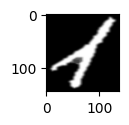

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(1, 1))
plt.imshow(img, cmap='gray')
plt.show()
# save image
plt.savefig('cells_grid.jpg', format='jpg', dpi=300)




In [21]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import requests

# load image from the IAM database
image = img
image = 255 - image

processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-handwritten')
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-handwritten')
pixel_values = processor(images=image, return_tensors="pt").pixel_values

generated_ids = model.generate(pixel_values)

generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]


Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.1"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

In [22]:
def eval_new_data(data_path=None, num_samples=4, model=None):
    image_paths = glob.glob(data_path)
    for i, image_path in tqdm(enumerate(image_paths), total=len(image_paths)):
        if i == num_samples:
            break
        image = read_image(image_path)
        text = ocr(image, processor, model)
        plt.figure(figsize=(7, 4))
        plt.imshow(image)
        plt.title(text)
        plt.axis('off')
        plt.show()

eval_new_data(
    data_path=os.path.join('images', 'newspaper', '*'),
    num_samples=2,
    model=model
)

'al'

(145, 138, 3)


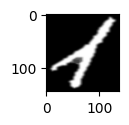

(145, 137, 3)


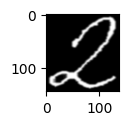

(145, 137, 3)


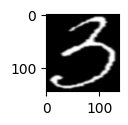

(145, 137, 3)


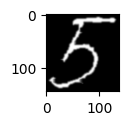

(148, 136, 3)


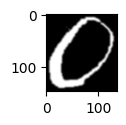

(148, 136, 3)


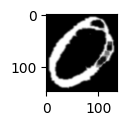

(148, 136, 3)


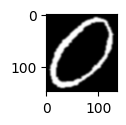

(148, 136, 3)


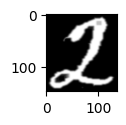

(154, 126, 3)


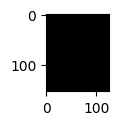

(154, 129, 3)


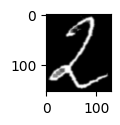

(154, 126, 3)


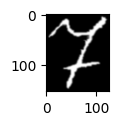

(154, 126, 3)


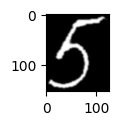

(155, 129, 3)


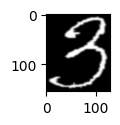

(155, 126, 3)


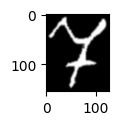

(155, 129, 3)


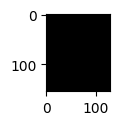

(155, 125, 3)


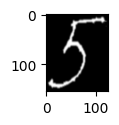

(155, 126, 3)


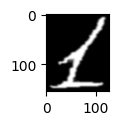

(155, 129, 3)


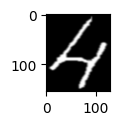

(155, 126, 3)


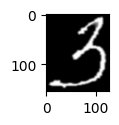

(155, 129, 3)


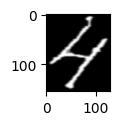

(155, 126, 3)


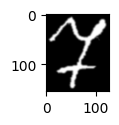

(155, 126, 3)


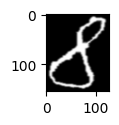

(154, 126, 3)


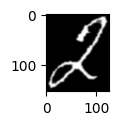

(154, 129, 3)


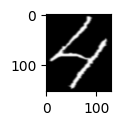

(154, 126, 3)


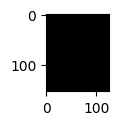

(154, 126, 3)


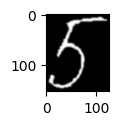

(154, 126, 3)


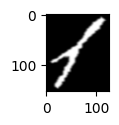

(154, 129, 3)


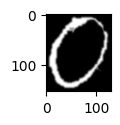

(154, 126, 3)


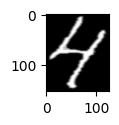

(154, 126, 3)


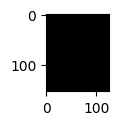

(154, 129, 3)


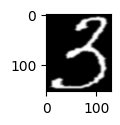

(154, 126, 3)


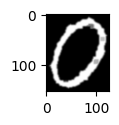

(154, 129, 3)


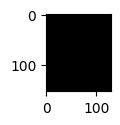

(154, 126, 3)


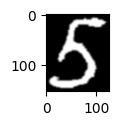

(154, 126, 3)


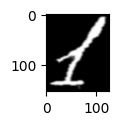

(154, 129, 3)


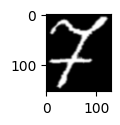

(154, 126, 3)


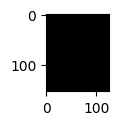

(154, 126, 3)


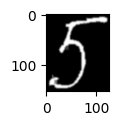

(154, 129, 3)


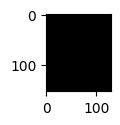

(154, 125, 3)


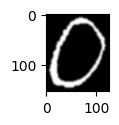

(154, 125, 3)


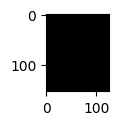

(154, 130, 3)


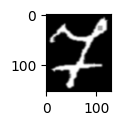

(154, 125, 3)


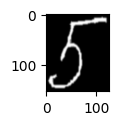

(154, 126, 3)


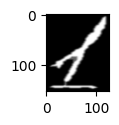

(154, 129, 3)


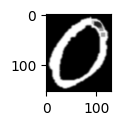

(154, 125, 3)


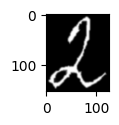

(154, 126, 3)


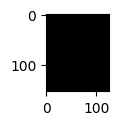

(154, 129, 3)


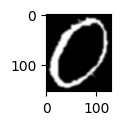

(154, 125, 3)


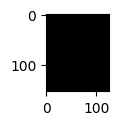

(154, 125, 3)


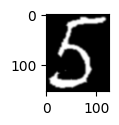

(145, 138, 3)


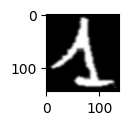

(145, 137, 3)


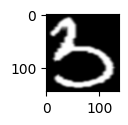

(145, 137, 3)


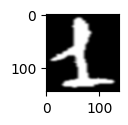

(145, 137, 3)


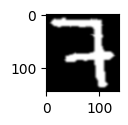

(148, 136, 3)


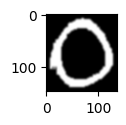

(148, 136, 3)


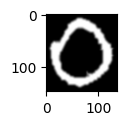

(148, 136, 3)


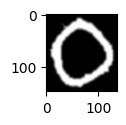

(148, 136, 3)


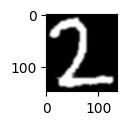

(154, 126, 3)


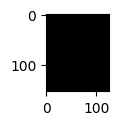

(154, 129, 3)


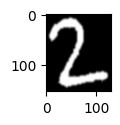

(154, 126, 3)


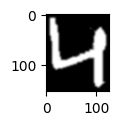

(154, 126, 3)


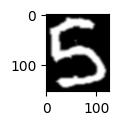

(155, 129, 3)


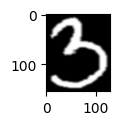

(155, 126, 3)


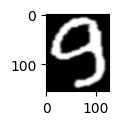

(155, 129, 3)


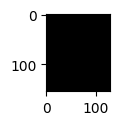

(155, 125, 3)


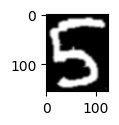

(155, 126, 3)


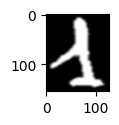

(155, 129, 3)


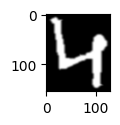

(155, 126, 3)


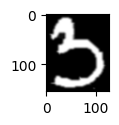

(155, 129, 3)


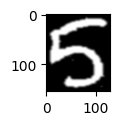

(155, 126, 3)


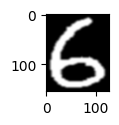

(155, 126, 3)


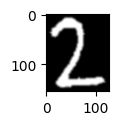

(154, 126, 3)


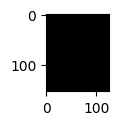

(154, 129, 3)


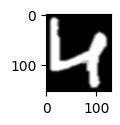

(154, 126, 3)


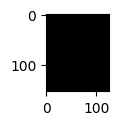

(154, 126, 3)


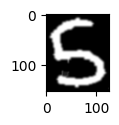

(154, 126, 3)


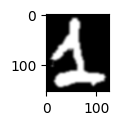

(154, 129, 3)


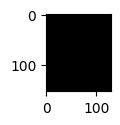

(154, 126, 3)


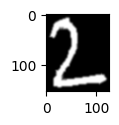

(154, 126, 3)


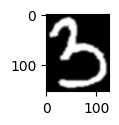

(154, 126, 3)


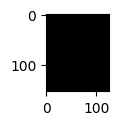

(154, 129, 3)


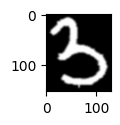

(145, 138, 3)


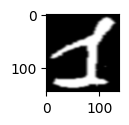

(145, 137, 3)


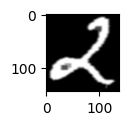

(145, 137, 3)


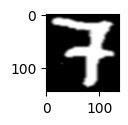

(145, 137, 3)


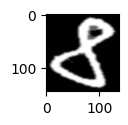

(148, 136, 3)


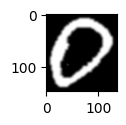

(148, 136, 3)


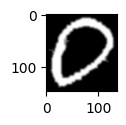

(148, 136, 3)


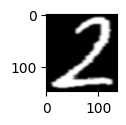

(154, 126, 3)


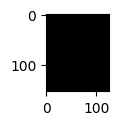

(154, 129, 3)


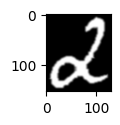

(154, 126, 3)


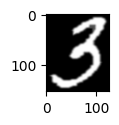

(154, 126, 3)


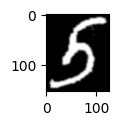

(155, 129, 3)


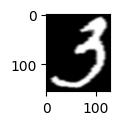

(155, 126, 3)


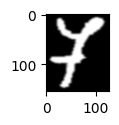

(155, 129, 3)


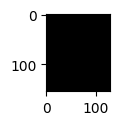

(155, 125, 3)


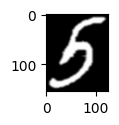

(155, 126, 3)


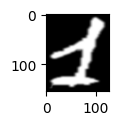

(155, 129, 3)


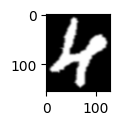

(155, 126, 3)


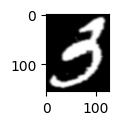

(155, 129, 3)


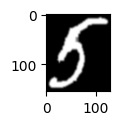

(155, 126, 3)


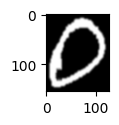

(155, 126, 3)


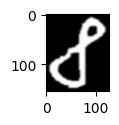

(154, 126, 3)


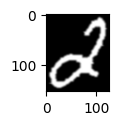

(154, 129, 3)


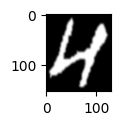

(154, 126, 3)


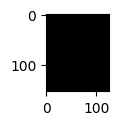

(154, 126, 3)


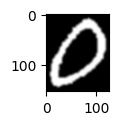

(154, 129, 3)


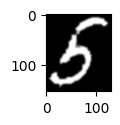

(154, 126, 3)


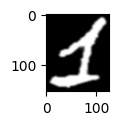

(154, 129, 3)


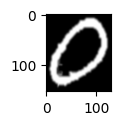

(154, 126, 3)


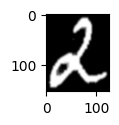

(154, 126, 3)


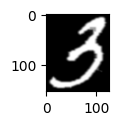

(154, 126, 3)


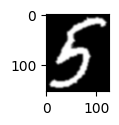

(154, 126, 3)


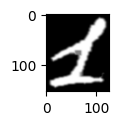

(154, 129, 3)


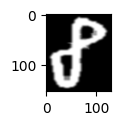

(154, 129, 3)


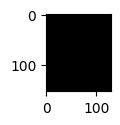

(154, 125, 3)


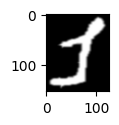

(145, 138, 3)


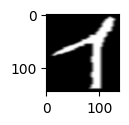

(145, 137, 3)


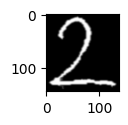

(145, 137, 3)


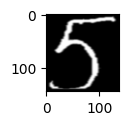

(145, 137, 3)


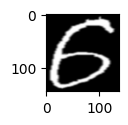

(148, 136, 3)


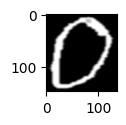

(148, 136, 3)


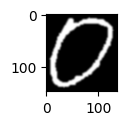

(148, 136, 3)


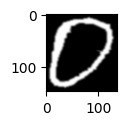

(148, 136, 3)


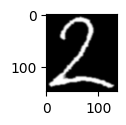

(154, 126, 3)


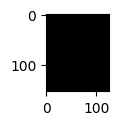

(154, 129, 3)


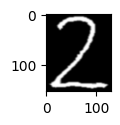

(154, 126, 3)


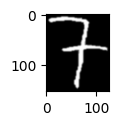

(154, 126, 3)


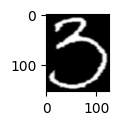

(155, 129, 3)


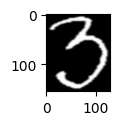

(155, 126, 3)


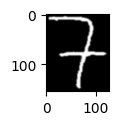

(155, 126, 3)


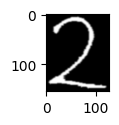

(155, 129, 3)


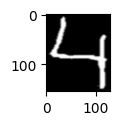

(155, 126, 3)


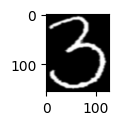

(155, 129, 3)


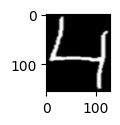

(155, 126, 3)


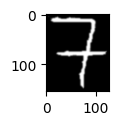

(155, 126, 3)


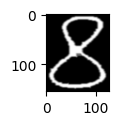

(154, 126, 3)


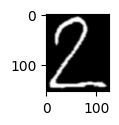

(154, 129, 3)


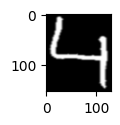

(154, 126, 3)


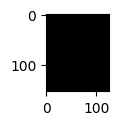

(154, 126, 3)


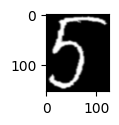

(154, 126, 3)


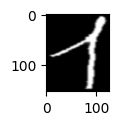

(154, 129, 3)


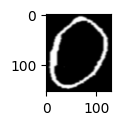

(154, 126, 3)


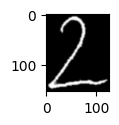

(154, 126, 3)


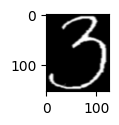

(154, 126, 3)


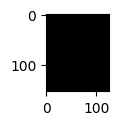

(154, 129, 3)


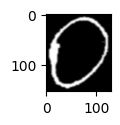

(154, 126, 3)


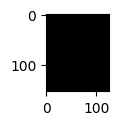

(154, 126, 3)


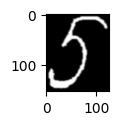

(154, 126, 3)


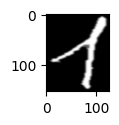

(154, 129, 3)


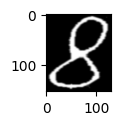

(154, 126, 3)


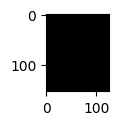

(154, 129, 3)


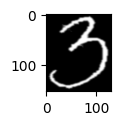

(145, 138, 3)


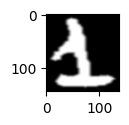

(145, 137, 3)


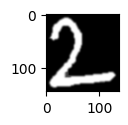

(145, 137, 3)


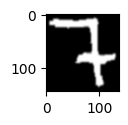

(145, 137, 3)


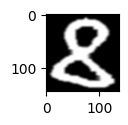

(148, 136, 3)


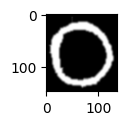

(148, 136, 3)


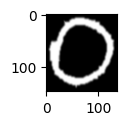

(148, 136, 3)


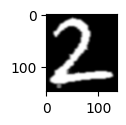

(154, 126, 3)


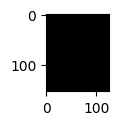

(154, 129, 3)


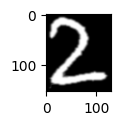

(154, 126, 3)


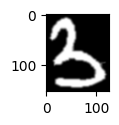

(154, 126, 3)


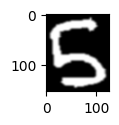

(155, 129, 3)


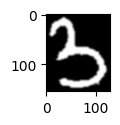

(155, 126, 3)


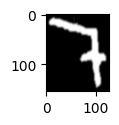

(155, 129, 3)


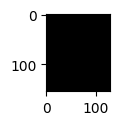

(155, 125, 3)


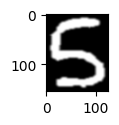

(155, 126, 3)


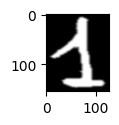

(155, 129, 3)


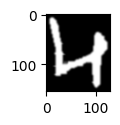

(155, 126, 3)


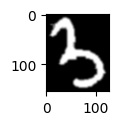

(155, 129, 3)


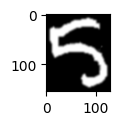

(155, 126, 3)


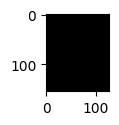

(155, 126, 3)


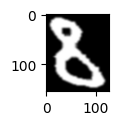

(154, 126, 3)


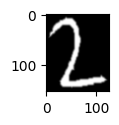

(154, 129, 3)


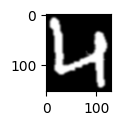

(154, 129, 3)


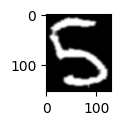

(154, 126, 3)


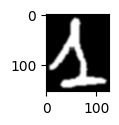

(154, 129, 3)


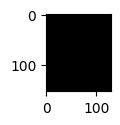

(154, 126, 3)


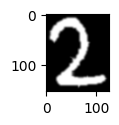

(154, 126, 3)


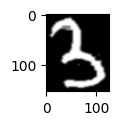

(154, 126, 3)


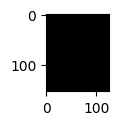

(154, 129, 3)


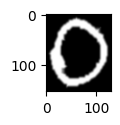

(154, 126, 3)


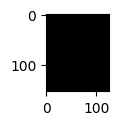

(154, 126, 3)


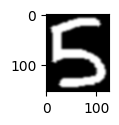

(154, 126, 3)


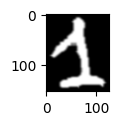

(154, 129, 3)


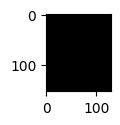

(154, 126, 3)


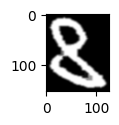

(154, 129, 3)


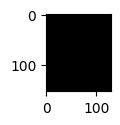

(154, 125, 3)


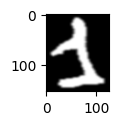

(145, 138, 3)


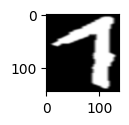

(145, 137, 3)


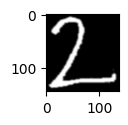

(145, 137, 3)


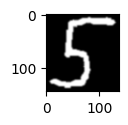

(145, 137, 3)


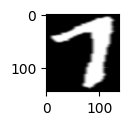

(148, 136, 3)


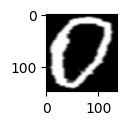

(148, 136, 3)


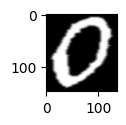

(148, 136, 3)


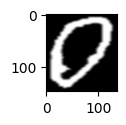

(148, 136, 3)


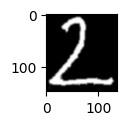

(154, 126, 3)


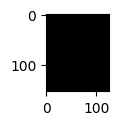

(154, 129, 3)


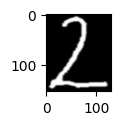

(154, 126, 3)


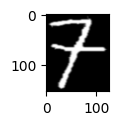

(154, 126, 3)


KeyboardInterrupt: 

In [45]:
import pickle

with open('cells_images_total.pkl', 'rb') as f:
    cells_images = pickle.load(f)

for cell_image in cells_images:
    print(cell_image.shape)
    plt.figure(figsize=(1, 1))
    plt.imshow(cell_image, cmap='gray')
    plt.show()



In [44]:
# from transformers import CLIPProcessor, CLIPModel, CLIPVisionModel
# from PIL import Image
# import torch
# import matplotlib.pyplot as plt
# import cv2
# import numpy as np
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# # Загружаем видовую модель, обученную для MNIST (весы для vision части)
# vision_model = CLIPVisionModel.from_pretrained('tanganke/clip-vit-base-patch32_emnist_letters').to(device)

# # Загружаем оригинальный CLIP-модель (мультимодальную)
# clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)

# # Подгружаем веса видовой модели (MNIST) в multimodal модель CLIP
# clip_model.vision_model.load_state_dict(vision_model.vision_model.state_dict())

# # Определяем текстовые метки для цифр от 1 до 9
# labels = ["zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine"]

# # Загружаем процессор для корректной предобработки изображений и текстов
# processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# def rotate_image(image, angle):
#     (h, w) = image.shape[:2]
#     # Define the rotation matrix
#     center = (w // 2, h // 2)
#     rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
#     rotated_image = cv2.warpAffine(image, rotation_matrix, (w, h))
#     return rotated_image


# def deskew_image(image):
#     """
#     Функция выравнивания изображения с цифрой (белая цифра на черном фоне) с помощью моментов.
    
#     Аргументы:
#         image: исходное изображение в градациях серого (grayscale).
        
#     Возвращает:
#         Выравненное изображение.
#     """
#     # Приводим изображение к бинарному виду.
#     # Если изображение уже бинарное, этот шаг можно опустить.
#     # Порог 128 выбирается как среднее значение между 0 и 255.
    
#     # Вычисляем пространственные моменты бинарного изображения

#     image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#     moments = cv2.moments(image)
    
#     # Если центральный момент второго порядка по y (mu02) очень мал, считать наклон равным 0
#     if abs(moments["mu02"]) < 1e-2:
#         return image.copy()
    
#     # Вычисляем угол наклона (в радианах)
#     # Используем функцию arctan2, которая учитывает знак числителя и знаменателя.
#     skew_rad = 0.5 * np.arctan2(2 * moments["mu11"], moments["mu20"] - moments["mu02"])
#     # Переводим угол в градусы
#     skew_deg = np.degrees(skew_rad)
    
#     # Для компенсации наклона поворачиваем изображение на -skew_deg градусов.
#     (h, w) = image.shape[:2]
#     center = (w // 2, h // 2)
#     M = cv2.getRotationMatrix2D(center, skew_deg, 1.0)
    
#     # Поворачиваем изображение. Используем INTER_LINEAR для интерполяции
#     # и BORDER_REPLICATE, чтобы избежать появления чёрных границ.
#     deskewed = cv2.warpAffine(image, M, (w, h),
#                               flags=cv2.INTER_LINEAR,
#                               borderMode=cv2.BORDER_REPLICATE)
    
#     deskewed = cv2.cvtColor(deskewed, cv2.COLOR_GRAY2BGR)
#     return deskewed

# def predict_digit(image, labels):
#     # Обрабатываем изображение и текстовые метки.
#     # Процессор создаст словарь с ключом "pixel_values" для изображения и "input_ids"/"attention_mask" для текста.
#     # resize image to 224x224
#     # image = cv2.resize(image, (32, 32))
#     # rotate image
#     # image = rotate_image(image, 15)
#     if np.sum(image) == 0:
#         return None, image
    
#     # kernel = np.ones((3,3), np.uint8)
#     # image = cv2.erode(image, kernel, iterations=1)
#     # image = deskew_image(image)
#     # image = cv2.resize(image, (28, 28))
#     # plt.figure(figsize=(1, 1))
#     # plt.imshow(image, cmap='gray')
#     # plt.show()
#     # расширяем изображение
#     image = cv2.copyMakeBorder(image, 10, 10, 10, 10, cv2.BORDER_REPLICATE)
#     image = rotate_image(image, 15)
#     # image = 255 - image
#     # image = cv2.resize(image, (28, 28))

#     inputs = processor(text=labels, images=image, return_tensors="pt", padding=True).to(device)


#     # Получаем выходы модели без вычисления градиентов
#     with torch.no_grad():
#         outputs = clip_model(**inputs)
#         # logits_per_image — это матрица сходства между изображением и каждым из текстовых описаний.
#         logits_per_image = outputs.logits_per_image  # размер: (1, число меток)
#         # Преобразуем логиты в вероятности по меткам.
#         probs = logits_per_image.softmax(dim=1)

#     # Определяем индекс метки с наибольшей вероятностью
#     pred_idx = probs.argmax(dim=1).item()
#     predicted_digit = labels[pred_idx]
#     three_best_probs_dict = dict(zip(labels, probs[0].tolist()))
#     three_best_probs_dict = sorted(three_best_probs_dict.items(), key=lambda x: x[1], reverse=True)[:3] 
#     print('predicted digit', predicted_digit)
#     plt.figure(figsize=(1, 1))
#     plt.imshow(image, cmap='gray')
#     plt.title(three_best_probs_dict)
#     plt.show()
#     return predicted_digit, image




# for cell_image in cells_images:
#     predicted_digit, cell_image = predict_digit(cell_image, labels)
#     # print('predicted digit', predicted_digit)
#     # plt.figure(figsize=(1, 1))
#     # plt.imshow(cell_image, cmap='gray')
#     # plt.show()


